In [ ]:
# Install libraries for google colab.
!pip install segmentation-models-pytorch torch torchmetrics albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 43.5 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=cc760b64e89e751a7863c2b6017291d0dd4443113970297501da30a4b2133ad9
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=ae4f4de7817e787b046e617c29124eca742a26ffe84182e959ac8605325a3a2d
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c601

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# PyTorch libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# Segmentation Models PyTorch
import segmentation_models_pytorch as smp

# Albumentations for data augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Torchmetrics for evaluation metrics
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.22 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:

# Set up the device to use GPU if avaliable, otherwise cpu.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_names, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_names = image_names
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        # Get image and mask paths
        image_name = self.image_names[idx]
        image_path = os.path.join(self.images_dir, image_name)
        mask_name = image_name.replace('.jpg', '_segmentation.png')
        mask_path = os.path.join(self.masks_dir, mask_name)

        # Load image and mask
        image = np.array(Image.open(image_path).convert('RGB'))
        mask = np.array(Image.open(mask_path).convert('L'), dtype=np.float32)
        # Ensure mask is binary (0 or 1)
        mask[mask > 0] = 1.0

        # Apply transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = TF.to_tensor(image)
            mask = torch.tensor(mask).unsqueeze(0)

        return image, mask

In [ ]:
# Define transformations for images and masks.
train_transforms = A.Compose([
    A.Resize(576, 448),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(576, 448),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
!unzip -q /content/drive/MyDrive/HAM10000 -d /content/

In [ ]:
# Paths to the images and masks directory.
images_dir = '/content/HAM10000/images/'
masks_dir = '/content/HAM10000/masks/'

# Get list of image names. Ignore files that are not .jpg or .png (as macOS adds hidden files).
image_names = [f for f in os.listdir(images_dir) if f.endswith('.jpg') or f.endswith('.png')]

# Split into training and validation sets
train_names, val_names = train_test_split(image_names, test_size=0.2, random_state=42)

# Create dataset instances
train_dataset = SkinLesionDataset(images_dir, masks_dir, train_names, transform=train_transforms)
val_dataset = SkinLesionDataset(images_dir, masks_dir, val_names, transform=val_transforms)

In [ ]:
# Create data loaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
# Define the U-Net model using segmentation_models_pytorch
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

# Move model to the device
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 345MB/s]


In [ ]:
# Loss function
loss_fn = smp.losses.DiceLoss(mode='binary')

In [ ]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
# Metrics
iou_metric = BinaryJaccardIndex().to(device)
accuracy_metric = BinaryAccuracy().to(device)

In [ ]:
num_epochs = 25

for epoch in range(num_epochs):
    # Train phase
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        # Ensure that the masks have shape [B, 1, H, W]
        masks = masks.to(device).float().unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)

    # Validation phase
    model.eval()
    val_loss = 0.0
    total_iou = 0.0
    total_acc = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device).float().unsqueeze(1)

            outputs = model(images)

            loss = loss_fn(outputs, masks)
            val_loss += loss.item() * images.size(0)

            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()

            # Flatten tensors for metrics computation
            preds_flat = preds.view(-1)
            masks_flat = masks.view(-1)

            # Compute metrics
            iou = iou_metric(preds_flat, masks_flat)
            acc = accuracy_metric(preds_flat, masks_flat)

            total_iou += iou.item() * images.size(0)
            total_acc += acc.item() * images.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_iou = total_iou / len(val_loader.dataset)
    avg_acc = total_acc / len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_iou:.4f}, Val Accuracy: {avg_acc:.4f}")

Epoch [1/25]
Train Loss: 0.2074
Val Loss: 0.1139, Val IoU: 0.8670, Val Accuracy: 0.9627
Epoch [2/25]
Train Loss: 0.0988
Val Loss: 0.0780, Val IoU: 0.8793, Val Accuracy: 0.9665
Epoch [3/25]
Train Loss: 0.0761
Val Loss: 0.0748, Val IoU: 0.8722, Val Accuracy: 0.9649
Epoch [4/25]
Train Loss: 0.0647
Val Loss: 0.0658, Val IoU: 0.8832, Val Accuracy: 0.9669
Epoch [5/25]
Train Loss: 0.0566
Val Loss: 0.0620, Val IoU: 0.8872, Val Accuracy: 0.9685
Epoch [6/25]
Train Loss: 0.0523
Val Loss: 0.0597, Val IoU: 0.8902, Val Accuracy: 0.9693
Epoch [7/25]
Train Loss: 0.0486
Val Loss: 0.0584, Val IoU: 0.8921, Val Accuracy: 0.9702
Epoch [8/25]
Train Loss: 0.0471
Val Loss: 0.0586, Val IoU: 0.8912, Val Accuracy: 0.9697
Epoch [9/25]
Train Loss: 0.0424
Val Loss: 0.0570, Val IoU: 0.8938, Val Accuracy: 0.9707
Epoch [10/25]
Train Loss: 0.0372
Val Loss: 0.0589, Val IoU: 0.8902, Val Accuracy: 0.9691
Epoch [11/25]
Train Loss: 0.0420
Val Loss: 0.0576, Val IoU: 0.8921, Val Accuracy: 0.9702
Epoch [12/25]
Train Loss: 0.03

In [ ]:
torch.save(model.state_dict(), "model2.pth")

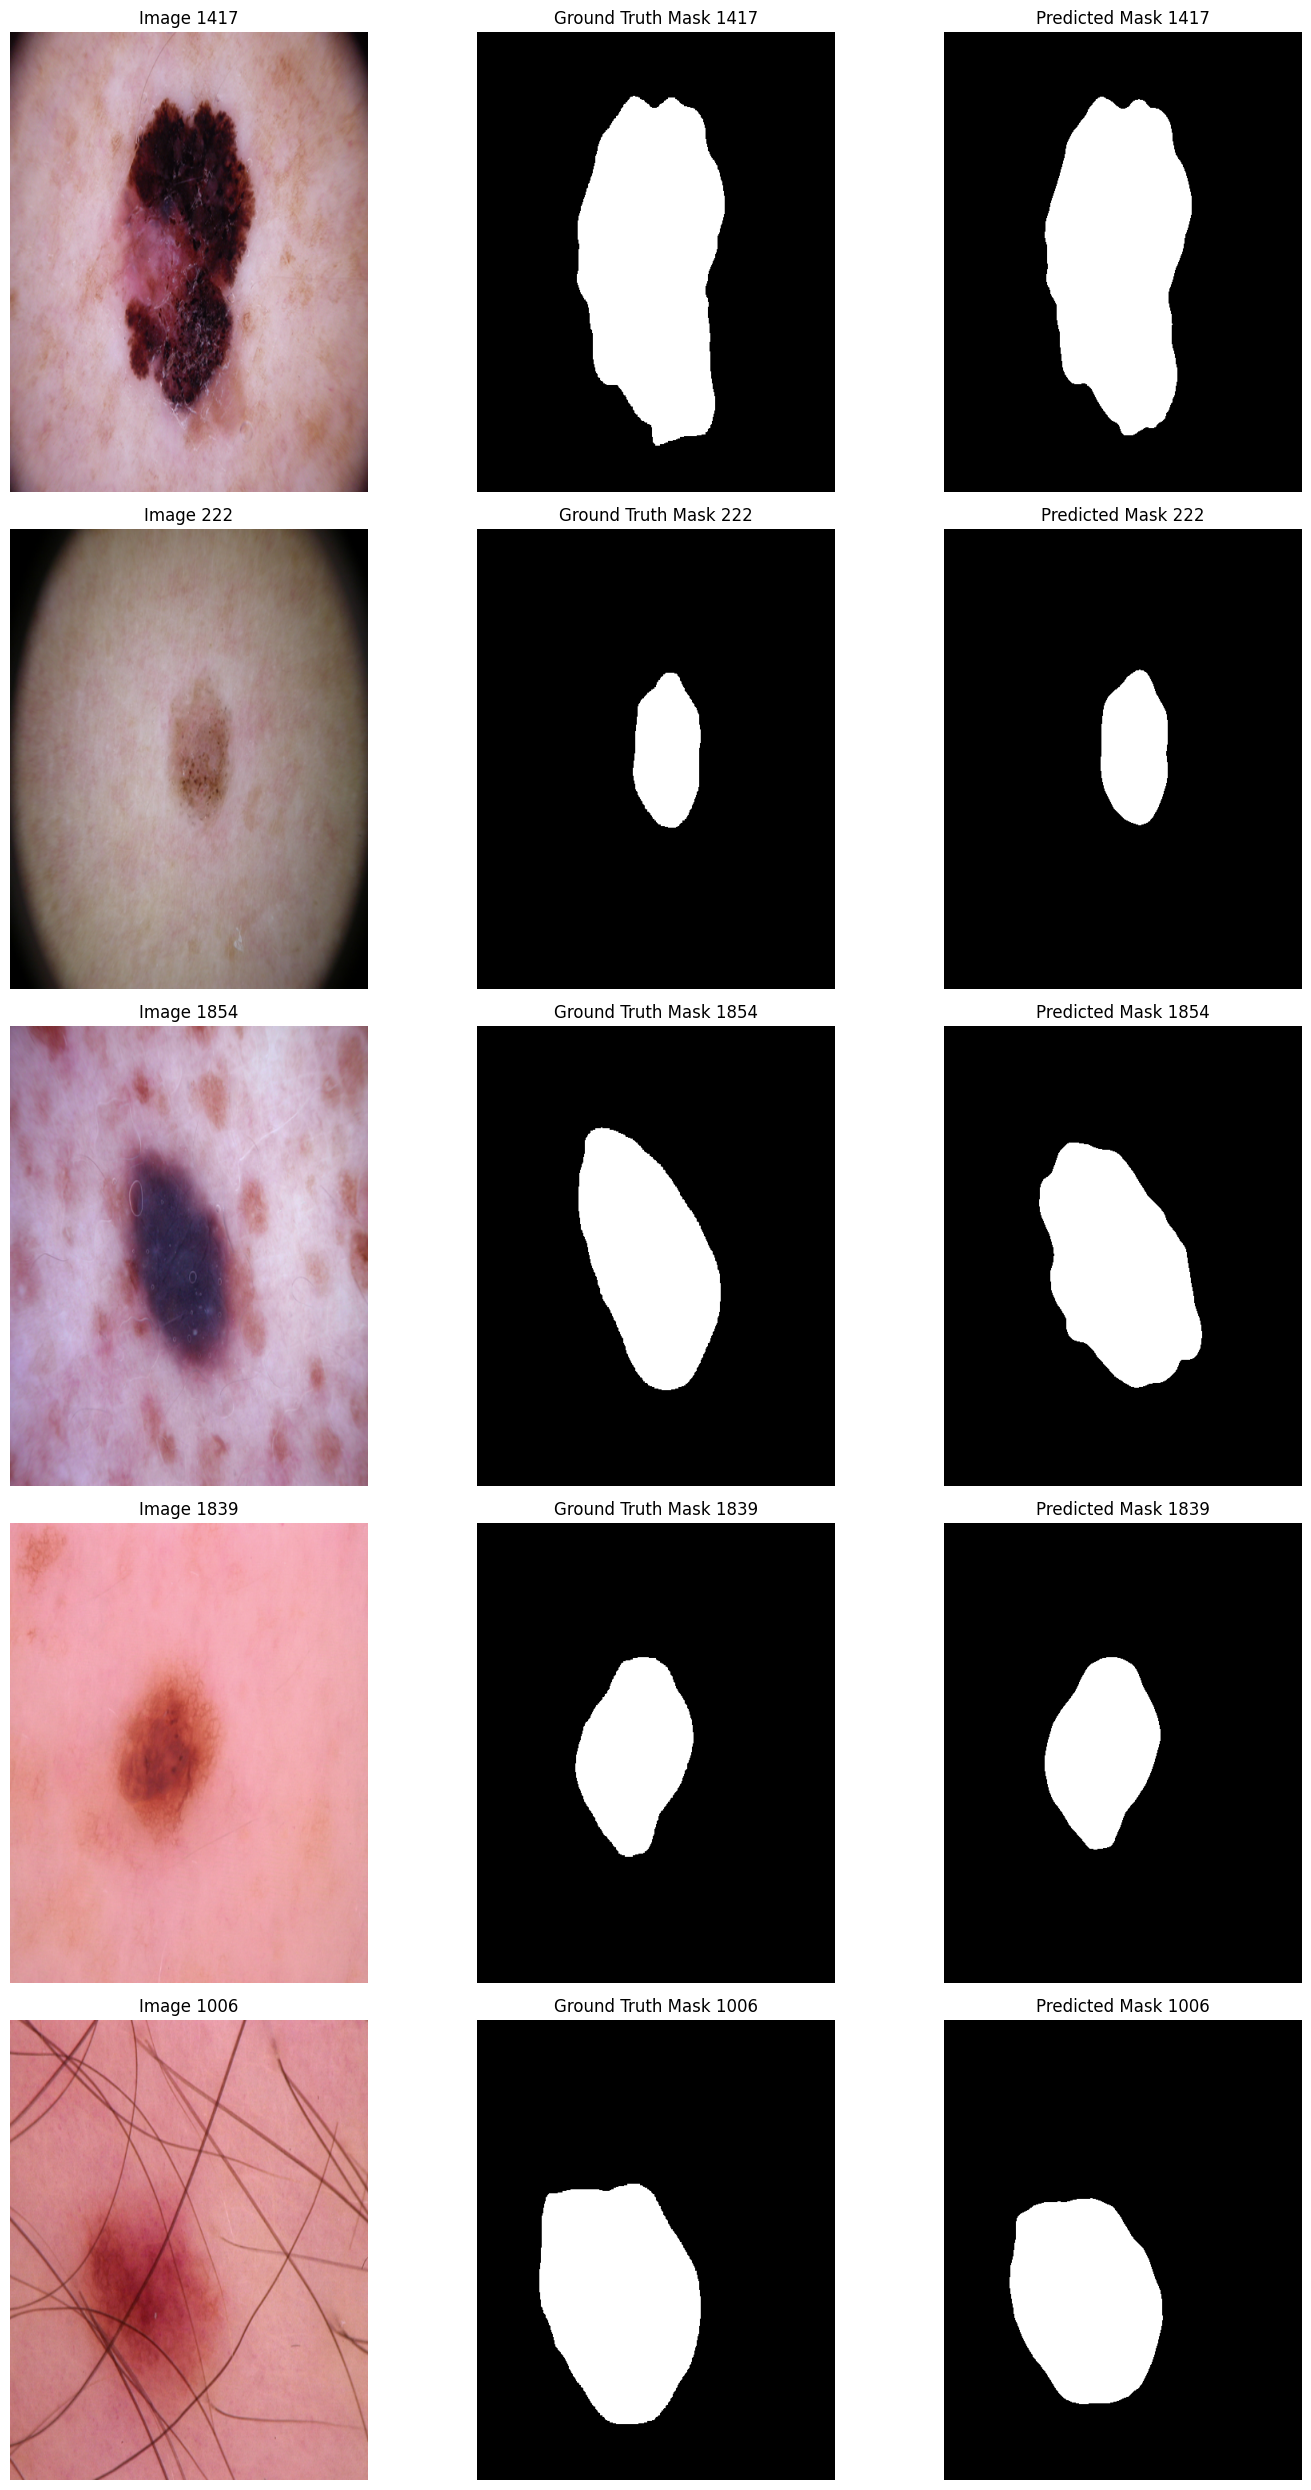

In [ ]:
import matplotlib.pyplot as plt
import random

# Number of samples to display
num_samples = 5

# Set the model to evaluation mode
model.eval()

# Visualize random samples from the validation dataset
with torch.no_grad():
    plt.figure(figsize=(15, num_samples * 5))
    for i in range(num_samples):
        # Randomly select an index from the validation dataset
        idx = random.randint(0, len(val_dataset) - 1)
        image, mask = val_dataset[idx]  # Fetch the image and ground truth mask
        image = image.to(device).unsqueeze(0)  # Add batch dimension
        mask = mask.cpu().numpy().squeeze()  # Convert ground truth mask to numpy array

        # Generate the prediction
        output = model(image)
        output = torch.sigmoid(output)  # Apply sigmoid activation
        predicted_mask = (output > 0.5).float().cpu().numpy().squeeze()  # Binarize predictions

        # Convert the image tensor to a numpy array for visualization
        image_np = image.cpu().numpy().squeeze().transpose(1, 2, 0)  # [C, H, W] -> [H, W, C]
        mean = np.array([0.485, 0.456, 0.406])  # Normalization mean
        std = np.array([0.229, 0.224, 0.225])  # Normalization std
        image_np = std * image_np + mean  # Reverse normalization
        image_np = np.clip(image_np, 0, 1)  # Ensure valid pixel range [0, 1]

        # Plot the input image
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(image_np)
        plt.title(f"Image {idx}")
        plt.axis("off")

        # Plot the ground truth mask
        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Ground Truth Mask {idx}")
        plt.axis("off")

        # Plot the predicted mask
        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(predicted_mask, cmap='gray')
        plt.title(f"Predicted Mask {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()